<a href="https://colab.research.google.com/github/TejashreeDV/Atharvo-final-project/blob/main/poly_Regression_with_SKlearn_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Fuel Consumption.csv", encoding='cp1252')

In [ ]:
df

,MODELYEAR,MAKE,MODEL,VEHICLE CLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION in CITY (L/100 km),FUEL CONSUMPTION in HWY (L/100 km),FUEL CONSUMPTION COMB (L/100 km),FUELCONSUMPTION_COMB,CO2EMISSIONS
0,NaN,NaN,# = high output engine,NaN,(L),NaN,NaN,TYPE,NaN,HWY (L/100 km),COMB (L/100 km),COMB (mpg),(g/km)
1,2014,ACURA,ILX,COMPACT,2,4.0,AS5,Z,9.9,6.7,8.5,33,196
2,2014,ACURA,ILX,COMPACT,2.4,4.0,M6,Z,11.2,7.7,9.6,29,221
3,2014,ACURA,ILX HYBRID,COMPACT,1.5,4.0,AV7,Z,6.0,5.8,5.9,48,136
4,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6.0,AS6,Z,12.7,9.1,11.1,25,255
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1092,NaN,D = Diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1093,NaN,E = Ethanol (E85),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1094,NaN,N = Natural Gas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1095,Fuel Consumption,City and highway fuel consumption ratings are ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dropna(axis = 0, inplace=True)

In [ ]:
df

,MODELYEAR,MAKE,MODEL,VEHICLE CLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION in CITY (L/100 km),FUEL CONSUMPTION in HWY (L/100 km),FUEL CONSUMPTION COMB (L/100 km),FUELCONSUMPTION_COMB,CO2EMISSIONS
1,2014,ACURA,ILX,COMPACT,2,4.0,AS5,Z,9.9,6.7,8.5,33,196
2,2014,ACURA,ILX,COMPACT,2.4,4.0,M6,Z,11.2,7.7,9.6,29,221
3,2014,ACURA,ILX HYBRID,COMPACT,1.5,4.0,AV7,Z,6.0,5.8,5.9,48,136
4,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6.0,AS6,Z,12.7,9.1,11.1,25,255
5,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6.0,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067,2014,VOLVO,XC60 AWD,SUV - SMALL,3,6.0,AS6,X,13.4,9.8,11.8,24,271
1068,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6.0,AS6,X,13.2,9.5,11.5,25,264
1069,2014,VOLVO,XC70 AWD,SUV - SMALL,3,6.0,AS6,X,13.4,9.8,11.8,24,271
1070,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6.0,AS6,X,12.9,9.3,11.3,25,260


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1071 entries, 1 to 1071
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   MODELYEAR                            1071 non-null   object 
 1   MAKE                                 1071 non-null   object 
 2   MODEL                                1071 non-null   object 
 3   VEHICLE CLASS                        1071 non-null   object 
 4   ENGINESIZE                           1071 non-null   object 
 5   CYLINDERS                            1071 non-null   float64
 6   TRANSMISSION                         1071 non-null   object 
 7   FUEL                                 1071 non-null   object 
 8   FUEL CONSUMPTION in CITY (L/100 km)  1071 non-null   float64
 9   FUEL CONSUMPTION in HWY (L/100 km)   1071 non-null   object 
 10  FUEL CONSUMPTION COMB (L/100 km)     1071 non-null   object 
 11  FUELCONSUMPTION_COMB          

In [ ]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINESIZE',
       'CYLINDERS', 'TRANSMISSION', 'FUEL',
       'FUEL CONSUMPTION in CITY (L/100 km)',
       'FUEL CONSUMPTION in HWY (L/100 km)',
       'FUEL CONSUMPTION COMB (L/100 km)', 'FUELCONSUMPTION_COMB',
       'CO2EMISSIONS'],
      dtype='object')

In [ ]:
df[["ENGINESIZE","FUEL CONSUMPTION in CITY (L/100 km)", "FUEL CONSUMPTION in HWY (L/100 km)", "FUEL CONSUMPTION COMB (L/100 km)", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]] = df[["ENGINESIZE","FUEL CONSUMPTION in CITY (L/100 km)", "FUEL CONSUMPTION in HWY (L/100 km)", "FUEL CONSUMPTION COMB (L/100 km)", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]].apply(pd.to_numeric)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1071 entries, 1 to 1071
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   MODELYEAR                            1071 non-null   object 
 1   MAKE                                 1071 non-null   object 
 2   MODEL                                1071 non-null   object 
 3   VEHICLE CLASS                        1071 non-null   object 
 4   ENGINESIZE                           1071 non-null   float64
 5   CYLINDERS                            1071 non-null   float64
 6   TRANSMISSION                         1071 non-null   object 
 7   FUEL                                 1071 non-null   object 
 8   FUEL CONSUMPTION in CITY (L/100 km)  1071 non-null   float64
 9   FUEL CONSUMPTION in HWY (L/100 km)   1071 non-null   float64
 10  FUEL CONSUMPTION COMB (L/100 km)     1071 non-null   float64
 11  FUELCONSUMPTION_COMB          

In [ ]:
df.describe()

,ENGINESIZE,CYLINDERS,FUEL CONSUMPTION in CITY (L/100 km),FUEL CONSUMPTION in HWY (L/100 km),FUEL CONSUMPTION COMB (L/100 km),FUELCONSUMPTION_COMB,CO2EMISSIONS
count,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000
mean,3.342577,5.788049,13.285901,9.467694,11.572082,26.464052,256.116713
std,1.415778,1.797425,4.106325,2.788940,3.484679,7.473465,63.530627
min,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2.000000,4.000000,10.200000,7.500000,9.000000,21.000000,207.000000
50%,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,4.300000,8.000000,15.600000,10.700000,13.350000,31.000000,294.000000
max,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [ ]:
df.corr()

,ENGINESIZE,CYLINDERS,FUEL CONSUMPTION in CITY (L/100 km),FUEL CONSUMPTION in HWY (L/100 km),FUEL CONSUMPTION COMB (L/100 km),FUELCONSUMPTION_COMB,CO2EMISSIONS
ENGINESIZE,1.000000,0.934399,0.832293,0.777429,0.819227,-0.807148,0.873327
CYLINDERS,0.934399,1.000000,0.797509,0.722297,0.776790,-0.769667,0.849863
FUEL CONSUMPTION in CITY (L/100 km),0.832293,0.797509,1.000000,0.964625,0.995412,-0.935874,0.898426
FUEL CONSUMPTION in HWY (L/100 km),0.777429,0.722297,0.964625,1.000000,0.985318,-0.892745,0.860668
FUEL CONSUMPTION COMB (L/100 km),0.819227,0.776790,0.995412,0.985318,1.000000,-0.927983,0.892222
FUELCONSUMPTION_COMB,-0.807148,-0.769667,-0.935874,-0.892745,-0.927983,1.000000,-0.906997
CO2EMISSIONS,0.873327,0.849863,0.898426,0.860668,0.892222,-0.906997,1.000000


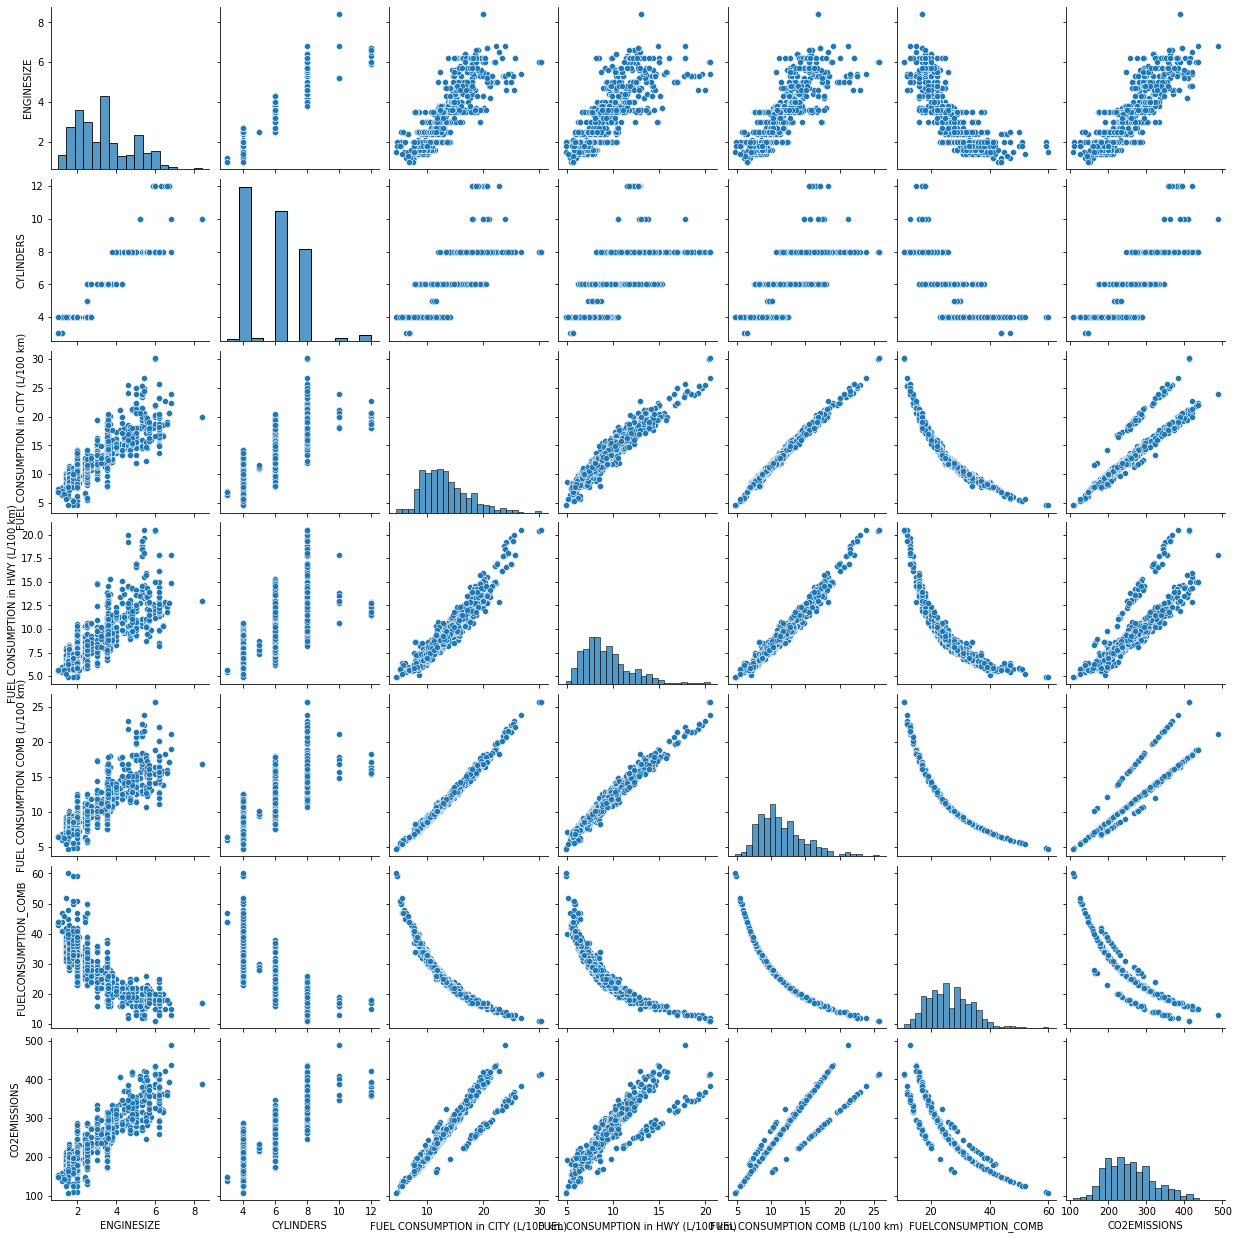

In [ ]:
sns.pairplot(df)

In [ ]:
X = df["FUELCONSUMPTION_COMB"]
y = df["CO2EMISSIONS"]

In [ ]:
X

1       33
2       29
3       48
4       25
5       27
        ..
1067    24
1068    25
1069    24
1070    25
1071    22
Name: FUELCONSUMPTION_COMB, Length: 1071, dtype: int64

In [ ]:
y

1       196
2       221
3       136
4       255
5       244
       ... 
1067    271
1068    264
1069    271
1070    260
1071    294
Name: CO2EMISSIONS, Length: 1071, dtype: int64

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
X = np.array(X).reshape(-1, 1)

In [ ]:
X

array([[33],
       [29],
       [48],
       ...,
       [24],
       [25],
       [22]])

In [ ]:
poly = PolynomialFeatures()
X = poly.fit_transform(X)

In [ ]:
X

array([[1.000e+00, 3.300e+01, 1.089e+03],
       [1.000e+00, 2.900e+01, 8.410e+02],
       [1.000e+00, 4.800e+01, 2.304e+03],
       ...,
       [1.000e+00, 2.400e+01, 5.760e+02],
       [1.000e+00, 2.500e+01, 6.250e+02],
       [1.000e+00, 2.200e+01, 4.840e+02]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [ ]:
X_train

array([[1.000e+00, 1.800e+01, 3.240e+02],
       [1.000e+00, 2.900e+01, 8.410e+02],
       [1.000e+00, 3.500e+01, 1.225e+03],
       ...,
       [1.000e+00, 3.100e+01, 9.610e+02],
       [1.000e+00, 2.100e+01, 4.410e+02],
       [1.000e+00, 2.800e+01, 7.840e+02]])

In [ ]:
#X_train = np.array(X_train).reshape(-1, 1) # do not do this step if you are using more column than 1
#X_test = np.array(X_test).reshape(-1, 1)

In [ ]:
X_train

array([[1.000e+00, 1.800e+01, 3.240e+02],
       [1.000e+00, 2.900e+01, 8.410e+02],
       [1.000e+00, 3.500e+01, 1.225e+03],
       ...,
       [1.000e+00, 3.100e+01, 9.610e+02],
       [1.000e+00, 2.100e+01, 4.410e+02],
       [1.000e+00, 2.800e+01, 7.840e+02]])

In [ ]:
X_train.shape

(749, 3)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression()

In [ ]:
model = reg.fit(X_train, y_train)

In [ ]:
model.coef_

array([  0.        , -16.00332433,   0.14215814])

In [ ]:
model.intercept_

573.1614053117011

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
mean_absolute_error(y_test, y_pred)

14.388500056506617

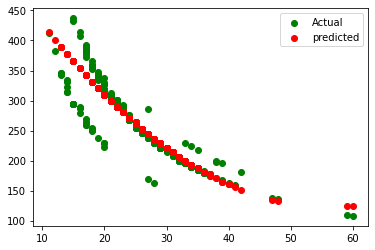

In [ ]:
plt.scatter(X_test[:, 1], y_test, c = "g", label = "Actual")
plt.scatter(X_test[:, 1], y_pred, c = "r", label = "predicted")
plt.legend()
plt.show()